In [1]:
from __future__ import absolute_import, division, print_function
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn.functional as F
from torchvision import transforms

# Jupyter magics
%matplotlib inline
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added to path: {project_root}")

# Local modules
from hsiData import HyperSkinData
from helpers import metrics
from hsiData.models.reconstruction import MST_Plus_Plus

Added to path: /home/gabriel/Hyper-Skin-2023


/home/gabriel/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Paths
data_dir = '/mnt/data/HyperSkin2023'
project_dir = '/home/gabriel/Hyper-Skin-2023'

rgbvis_dir = os.path.join(data_dir, 'Hyper-Skin(RGB, VIS)')
pretrained_dir = os.path.join(project_dir, 'Models', 'RGB-VIS')
results_dir = os.path.join(project_dir, 'evaluationResults')
os.makedirs(results_dir, exist_ok=True)

# Test folders
rgb_dir = os.path.join(rgbvis_dir, 'test', 'RGB')
vis_dir = os.path.join(rgbvis_dir, 'test', 'VIS')

# Evaluation configuration
BATCH_SIZE = 1
MODEL_NAME = 'MST_Plus_Plus_Up'
UPSCALE_FACTOR = 2
BAND_WAVELENGTHS = np.arange(400, 710, 10)  # 31 bands

# Output files
results_file_combined = os.path.join(results_dir, f'results_{MODEL_NAME.lower()}_combined.pkl')
results_file_lr = os.path.join(results_dir, f'results_{MODEL_NAME.lower()}_lr.pkl')
results_file_hr = os.path.join(results_dir, f'results_{MODEL_NAME.lower()}_hr.pkl')
print(f"Results will be saved to: {results_file_combined}")
print(f" - LR: {results_file_lr}")
print(f" - HR: {results_file_hr}")

Using device: cuda
Results will be saved to: /home/gabriel/Hyper-Skin-2023/evaluationResults/results_mst_plus_plus_up_combined.pkl
 - LR: /home/gabriel/Hyper-Skin-2023/evaluationResults/results_mst_plus_plus_up_lr.pkl
 - HR: /home/gabriel/Hyper-Skin-2023/evaluationResults/results_mst_plus_plus_up_hr.pkl


In [3]:
test_transform = transforms.Compose([
    transforms.ToTensor()
])

test_dataset = HyperSkinData.Load(
    hsi_dir=vis_dir,
    rgb_dir=rgb_dir,
    transform=test_transform
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True if device == 'cuda' else False
)

print(f"Test dataset loaded with {len(test_dataset)} samples.")

Test dataset loaded with 24 samples.


In [4]:
# NOTE: adjust checkpoint filename to your trained MST_Plus_Plus_LateUpsample weights
checkpoint_path = os.path.join(project_dir, 'saved-models', 'exp-MST_Plus_Plus_Up-CIE', 'model.pt')
print(f"Loading checkpoint from: {checkpoint_path}")

model = MST_Plus_Plus.MST_Plus_Plus_LateUpsample(
    in_channels=3, out_channels=31, n_feat=31, stage=3, upscale_factor=UPSCALE_FACTOR
)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint)
model.to(device)
model.eval()
print(f"Model '{MODEL_NAME}' loaded and set to evaluation mode.")

Loading checkpoint from: /home/gabriel/Hyper-Skin-2023/saved-models/exp-MST_Plus_Plus_Up-CIE/model.pt
Model 'MST_Plus_Plus_Up' loaded and set to evaluation mode.


In [5]:
def evaluate_return_mode(model, test_loader, return_hr=False, upscale_factor=2, device='cpu'):
    model.return_hr = return_hr
    results = {
        "file": [],
        "pred": [],
        "ssim_score": [],
        "ssim_map": [],
        "sam_score": [],
        "sam_map": []
    }

    metrics.ssim_fn.to(device)
    model.to(device)
    model.eval()

    for k, data in enumerate(test_loader):
        x, y = data
        x, y = x.float().to(device), y.float().to(device)

        with torch.no_grad():
            pred = model(x)  # LR or HR depending on model.return_hr

        # Match shapes for fair metrics computation
        if return_hr:
            # Upscale ground truth to HR to compare vs HR prediction
            y_metrics = F.interpolate(y, scale_factor=upscale_factor, mode='bilinear', align_corners=False)
            pred_metrics = pred
        else:
            # LR mode should already match GT size
            if pred.shape[-2:] != y.shape[-2:]:
                # Safety fallback: down/up sample pred to GT size
                pred_metrics = F.interpolate(pred, size=y.shape[-2:], mode='bilinear', align_corners=False)
            else:
                pred_metrics = pred
            y_metrics = y

        # Compute metrics
        ssim_score, ssim_map = metrics.ssim_fn(pred_metrics, y_metrics)
        sam_score,  sam_map  = metrics.sam_fn(pred_metrics, y_metrics)

        # File name
        base_filename = os.path.basename(test_dataset.rgb_files[k])
        filename_no_ext = os.path.splitext(base_filename)[0]
        results["file"].append(filename_no_ext)

        # Store
        results["pred"].append(pred.cpu().detach().numpy())
        results["ssim_score"].append(ssim_score.cpu().detach().numpy())
        results["ssim_map"].append(ssim_map.cpu().detach().numpy())
        results["sam_score"].append(sam_score.cpu().detach().numpy())
        results["sam_map"].append(sam_map.cpu().detach().numpy())

        mode_str = "HR" if return_hr else "LR"
        print(f"[{mode_str}] Test [{k+1}/{len(test_loader)}]: {results['file'][-1]}, "
              f"SSIM: {np.squeeze(results['ssim_score'][-1])}, "
              f"SAM: {np.squeeze(results['sam_score'][-1])}")

    return results

In [6]:
print("Running LR evaluation...")
results_lr = evaluate_return_mode(model, test_loader, return_hr=False, upscale_factor=UPSCALE_FACTOR, device=device)

print("\nRunning HR evaluation (spatially upscaled output)...")
results_hr = evaluate_return_mode(model, test_loader, return_hr=True, upscale_factor=UPSCALE_FACTOR, device=device)

# Combined nested dict
results_combined = {
    "LR": results_lr,
    "HR": results_hr,
    "meta": {
        "model": MODEL_NAME,
        "upscale_factor": UPSCALE_FACTOR,
        "band_wavelengths": BAND_WAVELENGTHS
    }
}

with open(results_file_lr, 'wb') as f:
    pickle.dump(results_lr, f)
with open(results_file_hr, 'wb') as f:
    pickle.dump(results_hr, f)
with open(results_file_combined, 'wb') as f:
    pickle.dump(results_combined, f)

print("\nEvaluation complete.")
print(f"Saved: {results_file_lr}")
print(f"Saved: {results_file_hr}")
print(f"Saved: {results_file_combined}")


Running LR evaluation...
[LR] Test [1/24]: p002_neutral_front, SSIM: 0.9167901277542114, SAM: 0.21340225636959076
[LR] Test [2/24]: p002_neutral_left, SSIM: 0.929218590259552, SAM: 0.20435751974582672
[LR] Test [3/24]: p002_neutral_right, SSIM: 0.9320544600486755, SAM: 0.19191262125968933
[LR] Test [4/24]: p002_smile_front, SSIM: 0.9261486530303955, SAM: 0.1996535062789917
[LR] Test [5/24]: p002_smile_left, SSIM: 0.9138813614845276, SAM: 0.2018798291683197
[LR] Test [6/24]: p002_smile_right, SSIM: 0.9374820590019226, SAM: 0.1893460750579834
[LR] Test [7/24]: p035_neutral_front, SSIM: 0.9370556473731995, SAM: 0.12609314918518066


[LR] Test [8/24]: p035_neutral_left, SSIM: 0.9342317581176758, SAM: 0.13302907347679138
[LR] Test [9/24]: p035_neutral_right, SSIM: 0.9371991753578186, SAM: 0.1195387989282608
[LR] Test [10/24]: p035_smile_front, SSIM: 0.9404816627502441, SAM: 0.12722574174404144
[LR] Test [11/24]: p035_smile_left, SSIM: 0.9416125416755676, SAM: 0.13584637641906738
[LR] Test [12/24]: p035_smile_right, SSIM: 0.9439855813980103, SAM: 0.12102387845516205
[LR] Test [13/24]: p036_neutral_front, SSIM: 0.950928807258606, SAM: 0.11744505167007446
[LR] Test [14/24]: p036_neutral_left, SSIM: 0.9402526021003723, SAM: 0.12924998998641968
[LR] Test [15/24]: p036_neutral_right, SSIM: 0.9419819712638855, SAM: 0.11857935786247253
[LR] Test [16/24]: p036_smile_front, SSIM: 0.9467950463294983, SAM: 0.12252888828516006
[LR] Test [17/24]: p036_smile_left, SSIM: 0.9386261105537415, SAM: 0.12816211581230164
[LR] Test [18/24]: p036_smile_right, SSIM: 0.9480327367782593, SAM: 0.11867062747478485
[LR] Test [19/24]: p039_neutra

In [7]:
ssim_scores_lr = np.array(results_lr["ssim_score"]).squeeze()
sam_scores_lr  = np.array(results_lr["sam_score"]).squeeze()

ssim_scores_hr = np.array(results_hr["ssim_score"]).squeeze()
sam_scores_hr  = np.array(results_hr["sam_score"]).squeeze()

print("--- Overall Model Performance (LR) ---")
print(f"SSIM (LR): {np.mean(ssim_scores_lr):.4f} ± {np.std(ssim_scores_lr):.4f} (higher is better)")
print(f"SAM  (LR): {np.mean(sam_scores_lr):.4f} ± {np.std(sam_scores_lr):.4f} (lower is better)")

print("\n--- Overall Model Performance (HR, vs upscaled GT) ---")
print(f"SSIM (HR): {np.mean(ssim_scores_hr):.4f} ± {np.std(ssim_scores_hr):.4f} (higher is better)")
print(f"SAM  (HR): {np.mean(sam_scores_hr):.4f} ± {np.std(sam_scores_hr):.4f} (lower is better)")

--- Overall Model Performance (LR) ---
SSIM (LR): 0.9383 ± 0.0091 (higher is better)
SAM  (LR): 0.1442 ± 0.0329 (lower is better)

--- Overall Model Performance (HR, vs upscaled GT) ---
SSIM (HR): 0.8156 ± 0.0181 (higher is better)
SAM  (HR): 0.2393 ± 0.0269 (lower is better)


--- Analyzing Sample #6: p035_neutral_front ---


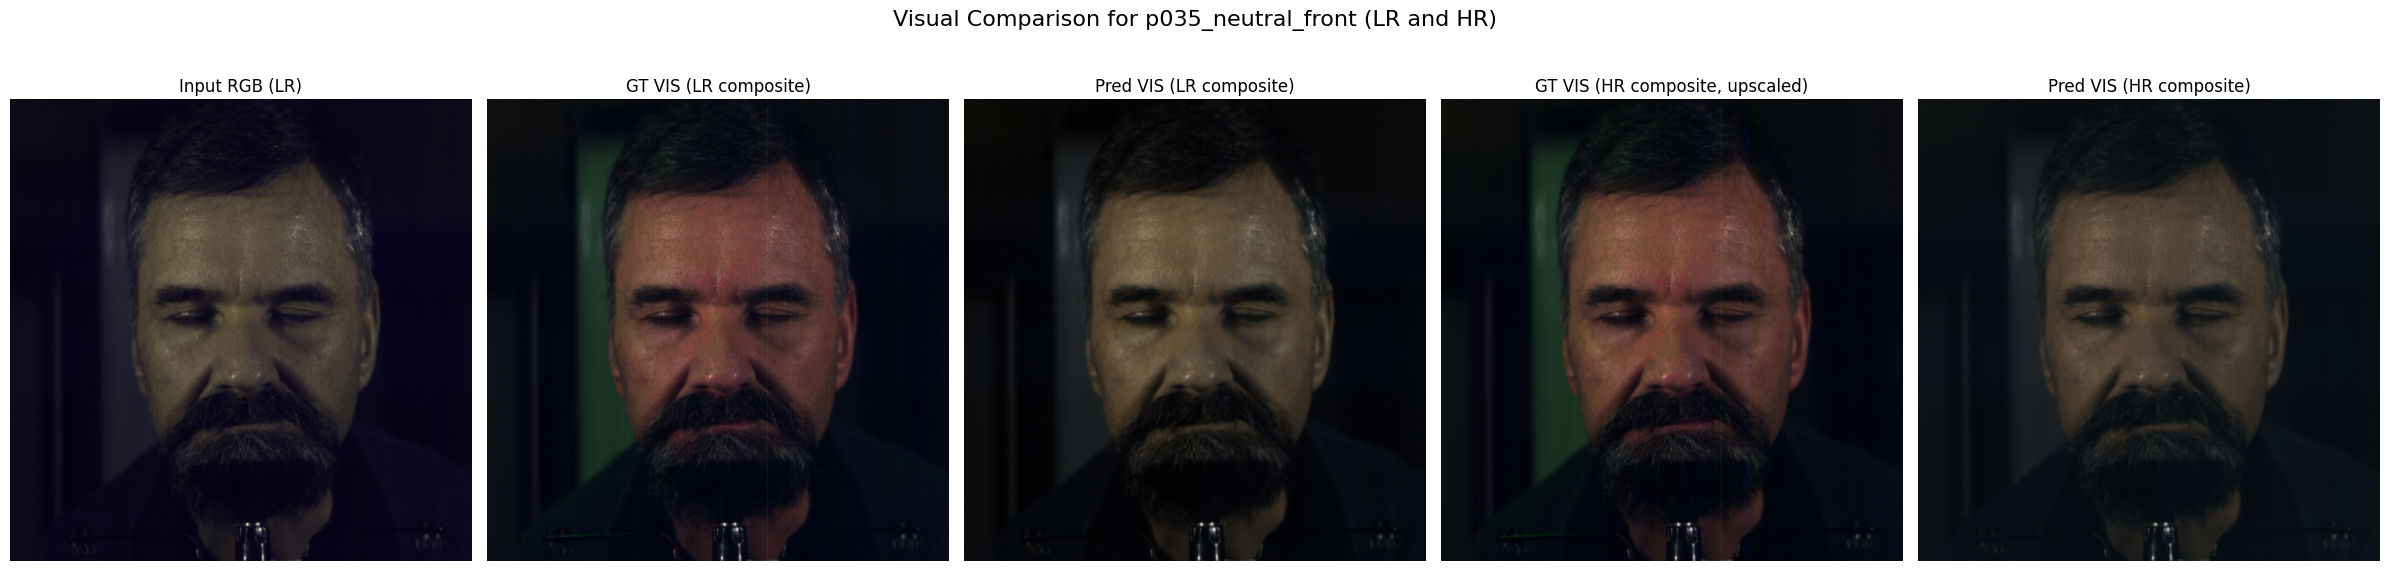

In [8]:
# Choose a sample index to analyze
sample_idx = 6
filename = results_lr['file'][sample_idx]
print(f"--- Analyzing Sample #{sample_idx}: {filename} ---")

# Fetch data and predictions
x_tensor, y_gt_tensor = test_dataset[sample_idx]
y_lr = y_gt_tensor.numpy()                                    # [C,H,W]
p_lr = np.array(results_lr["pred"]).squeeze()[sample_idx]     # [C,H,W]
p_hr = np.array(results_hr["pred"]).squeeze()[sample_idx]     # [C,H*r,W*r]

# Upscale GT to HR for visualization
y_hr_t = F.interpolate(y_gt_tensor.unsqueeze(0), scale_factor=UPSCALE_FACTOR, mode='bilinear', align_corners=False)
y_hr = y_hr_t.squeeze(0).numpy()

def create_rgb_composite(hsi_cube, wavelengths):
    # Returns HxWx3 composite
    rgb_indices = [np.argmin(np.abs(wavelengths - wl)) for wl in (610, 550, 460)]
    rgb_bands = hsi_cube[rgb_indices, :, :].copy()
    for i in range(rgb_bands.shape[0]):
        min_val, max_val = rgb_bands[i].min(), rgb_bands[i].max()
        if max_val > min_val:
            rgb_bands[i] = (rgb_bands[i] - min_val) / (max_val - min_val)
    return np.transpose(rgb_bands, (1, 2, 0))

# Build composites
inp_rgb = x_tensor.permute(1, 2, 0).numpy()
gt_vis_rgb_lr  = create_rgb_composite(y_lr, BAND_WAVELENGTHS)
pred_vis_rgb_lr = create_rgb_composite(p_lr, BAND_WAVELENGTHS)

gt_vis_rgb_hr  = create_rgb_composite(y_hr, BAND_WAVELENGTHS)
pred_vis_rgb_hr = create_rgb_composite(p_hr, BAND_WAVELENGTHS)

# Plot
fig, axs = plt.subplots(1, 5, figsize=(24, 6))
fig.suptitle(f'Visual Comparison for {filename} (LR and HR)', fontsize=16)

axs[0].imshow(inp_rgb)
axs[0].set_title('Input RGB (LR)')
axs[0].axis('off')

axs[1].imshow(gt_vis_rgb_lr)
axs[1].set_title('GT VIS (LR composite)')
axs[1].axis('off')

axs[2].imshow(pred_vis_rgb_lr)
axs[2].set_title('Pred VIS (LR composite)')
axs[2].axis('off')

axs[3].imshow(gt_vis_rgb_hr)
axs[3].set_title('GT VIS (HR composite, upscaled)')
axs[3].axis('off')

axs[4].imshow(pred_vis_rgb_hr)
axs[4].set_title('Pred VIS (HR composite)')
axs[4].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

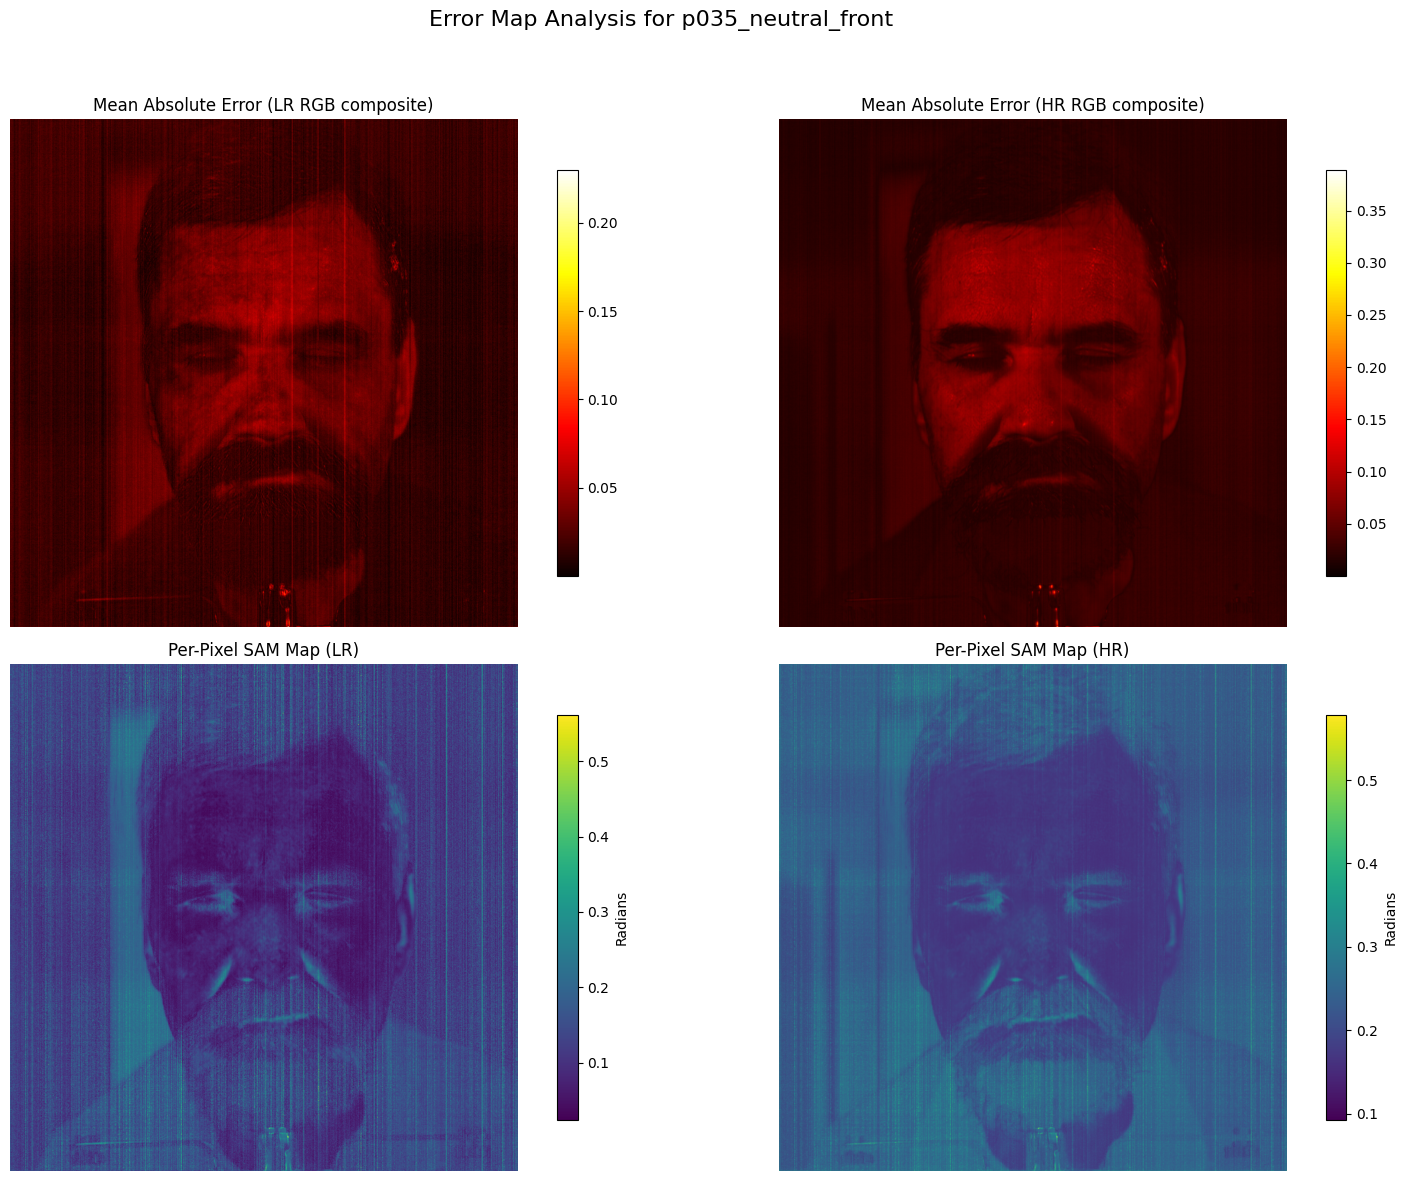

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Error Map Analysis for {filename}', fontsize=16)

# LR Absolute Error on RGB composite
abs_error_lr = np.mean(np.abs(gt_vis_rgb_lr - pred_vis_rgb_lr), axis=2)
im1 = axs[0,0].imshow(abs_error_lr, cmap='hot')
axs[0,0].set_title('Mean Absolute Error (LR RGB composite)')
axs[0,0].axis('off')
plt.colorbar(im1, ax=axs[0,0], shrink=0.8)

# HR Absolute Error on RGB composite
abs_error_hr = np.mean(np.abs(gt_vis_rgb_hr - pred_vis_rgb_hr), axis=2)
im2 = axs[0,1].imshow(abs_error_hr, cmap='hot')
axs[0,1].set_title('Mean Absolute Error (HR RGB composite)')
axs[0,1].axis('off')
plt.colorbar(im2, ax=axs[0,1], shrink=0.8)

# LR Per-Pixel SAM Map
sam_map_lr_flat = np.array(results_lr["sam_map"])[sample_idx].squeeze()
H_lr, W_lr = y_lr.shape[1], y_lr.shape[2]
sam_map_lr = sam_map_lr_flat.reshape(H_lr, W_lr)
im3 = axs[1,0].imshow(sam_map_lr, cmap='viridis')
axs[1,0].set_title('Per-Pixel SAM Map (LR)')
axs[1,0].axis('off')
plt.colorbar(im3, ax=axs[1,0], shrink=0.8, label='Radians')

# HR Per-Pixel SAM Map
sam_map_hr_flat = np.array(results_hr["sam_map"])[sample_idx].squeeze()
H_hr, W_hr = y_hr.shape[1], y_hr.shape[2]
sam_map_hr = sam_map_hr_flat.reshape(H_hr, W_hr)
im4 = axs[1,1].imshow(sam_map_hr, cmap='viridis')
axs[1,1].set_title('Per-Pixel SAM Map (HR)')
axs[1,1].axis('off')
plt.colorbar(im4, ax=axs[1,1], shrink=0.8, label='Radians')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

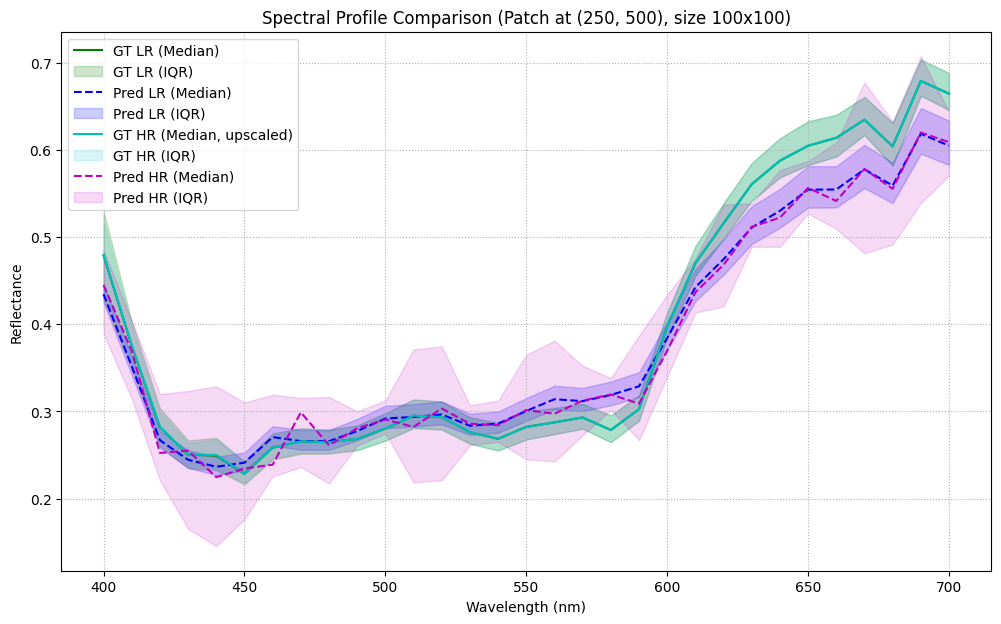

In [10]:
h, w, hwsize = 250, 500, 100

# LR patch
yy_lr = y_lr[:, h:h+hwsize, w:w+hwsize].reshape(y_lr.shape[0], -1)
pp_lr = p_lr[:, h:h+hwsize, w:w+hwsize].reshape(p_lr.shape[0], -1)

# HR patch (scaled coordinates)
r = UPSCALE_FACTOR
yy_hr = y_hr[:, h*r:(h+hwsize)*r, w*r:(w+hwsize)*r].reshape(y_hr.shape[0], -1)
pp_hr = p_hr[:, h*r:(h+hwsize)*r, w*r:(w+hwsize)*r].reshape(p_hr.shape[0], -1)

# Summaries
yy_lr_median, yy_lr_min, yy_lr_max = np.median(yy_lr, axis=1), np.percentile(yy_lr, 25, axis=1), np.percentile(yy_lr, 75, axis=1)
pp_lr_median, pp_lr_min, pp_lr_max = np.median(pp_lr, axis=1), np.percentile(pp_lr, 25, axis=1), np.percentile(pp_lr, 75, axis=1)

yy_hr_median, yy_hr_min, yy_hr_max = np.median(yy_hr, axis=1), np.percentile(yy_hr, 25, axis=1), np.percentile(yy_hr, 75, axis=1)
pp_hr_median, pp_hr_min, pp_hr_max = np.median(pp_hr, axis=1), np.percentile(pp_hr, 25, axis=1), np.percentile(pp_hr, 75, axis=1)

plt.figure(figsize=(12, 7))
# LR
plt.plot(BAND_WAVELENGTHS, yy_lr_median, 'g-', label='GT LR (Median)')
plt.fill_between(BAND_WAVELENGTHS, yy_lr_min, yy_lr_max, color='g', alpha=0.2, label='GT LR (IQR)')

plt.plot(BAND_WAVELENGTHS, pp_lr_median, 'b--', label='Pred LR (Median)')
plt.fill_between(BAND_WAVELENGTHS, pp_lr_min, pp_lr_max, color='b', alpha=0.2, label='Pred LR (IQR)')

# HR
plt.plot(BAND_WAVELENGTHS, yy_hr_median, 'c-', label='GT HR (Median, upscaled)')
plt.fill_between(BAND_WAVELENGTHS, yy_hr_min, yy_hr_max, color='c', alpha=0.15, label='GT HR (IQR)')

plt.plot(BAND_WAVELENGTHS, pp_hr_median, 'm--', label='Pred HR (Median)')
plt.fill_between(BAND_WAVELENGTHS, pp_hr_min, pp_hr_max, color='m', alpha=0.15, label='Pred HR (IQR)')

plt.title(f'Spectral Profile Comparison (Patch at ({h}, {w}), size {hwsize}x{hwsize})')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()


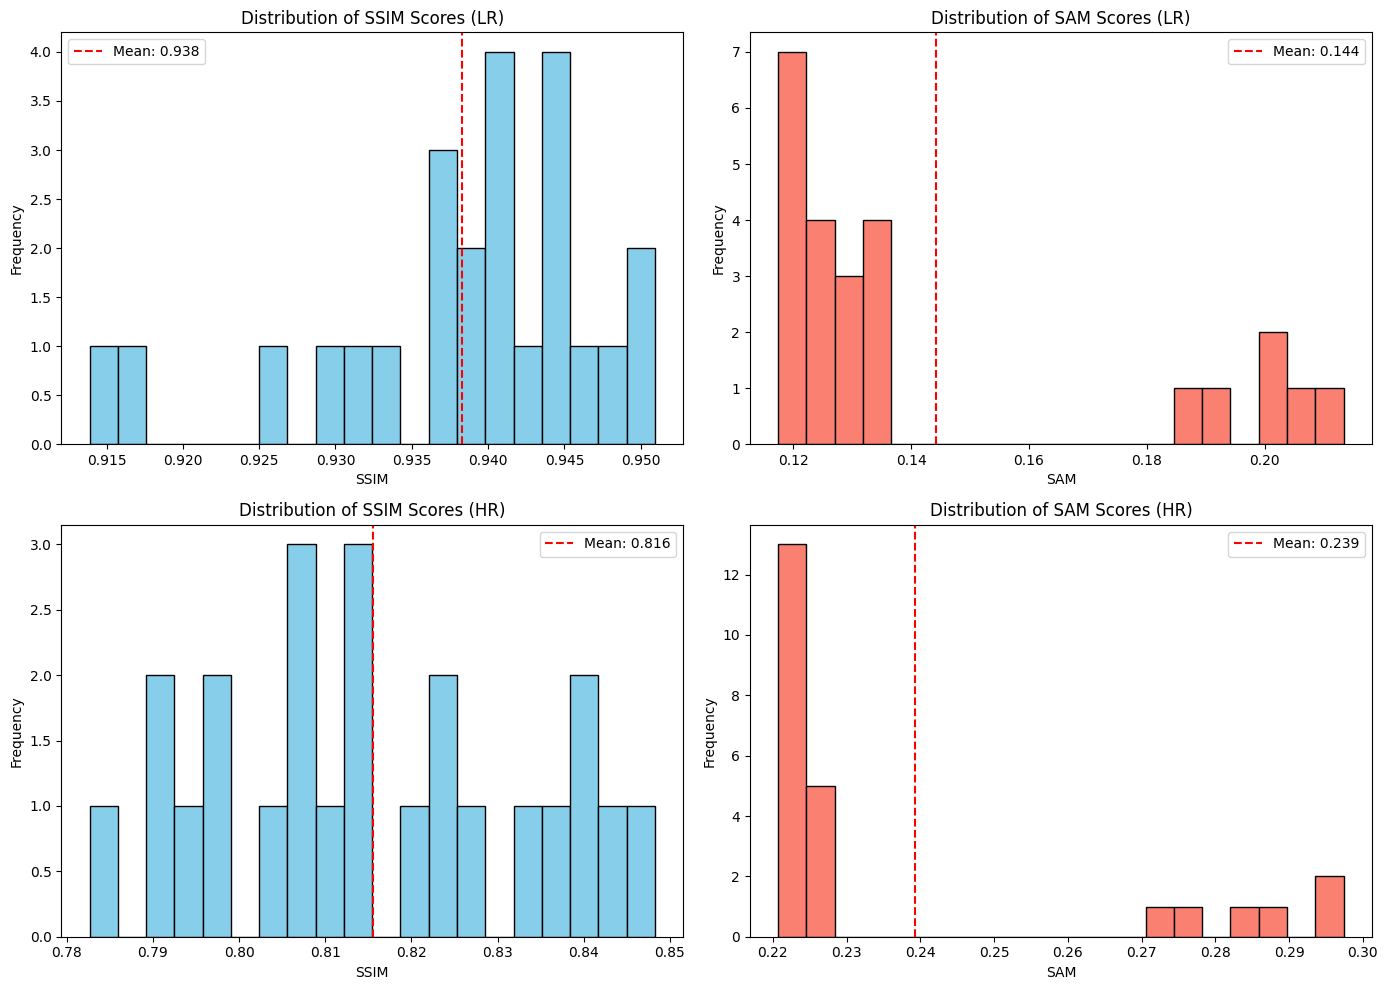

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0,0].hist(ssim_scores_lr, bins=20, color='skyblue', edgecolor='black')
axs[0,0].set_title('Distribution of SSIM Scores (LR)')
axs[0,0].set_xlabel('SSIM')
axs[0,0].set_ylabel('Frequency')
axs[0,0].axvline(ssim_scores_lr.mean(), color='r', linestyle='--', label=f'Mean: {ssim_scores_lr.mean():.3f}')
axs[0,0].legend()

axs[0,1].hist(sam_scores_lr, bins=20, color='salmon', edgecolor='black')
axs[0,1].set_title('Distribution of SAM Scores (LR)')
axs[0,1].set_xlabel('SAM')
axs[0,1].set_ylabel('Frequency')
axs[0,1].axvline(sam_scores_lr.mean(), color='r', linestyle='--', label=f'Mean: {sam_scores_lr.mean():.3f}')
axs[0,1].legend()

axs[1,0].hist(ssim_scores_hr, bins=20, color='skyblue', edgecolor='black')
axs[1,0].set_title('Distribution of SSIM Scores (HR)')
axs[1,0].set_xlabel('SSIM')
axs[1,0].set_ylabel('Frequency')
axs[1,0].axvline(ssim_scores_hr.mean(), color='r', linestyle='--', label=f'Mean: {ssim_scores_hr.mean():.3f}')
axs[1,0].legend()

axs[1,1].hist(sam_scores_hr, bins=20, color='salmon', edgecolor='black')
axs[1,1].set_title('Distribution of SAM Scores (HR)')
axs[1,1].set_xlabel('SAM')
axs[1,1].set_ylabel('Frequency')
axs[1,1].axvline(sam_scores_hr.mean(), color='r', linestyle='--', label=f'Mean: {sam_scores_hr.mean():.3f}')
axs[1,1].legend()

plt.tight_layout()
plt.show()


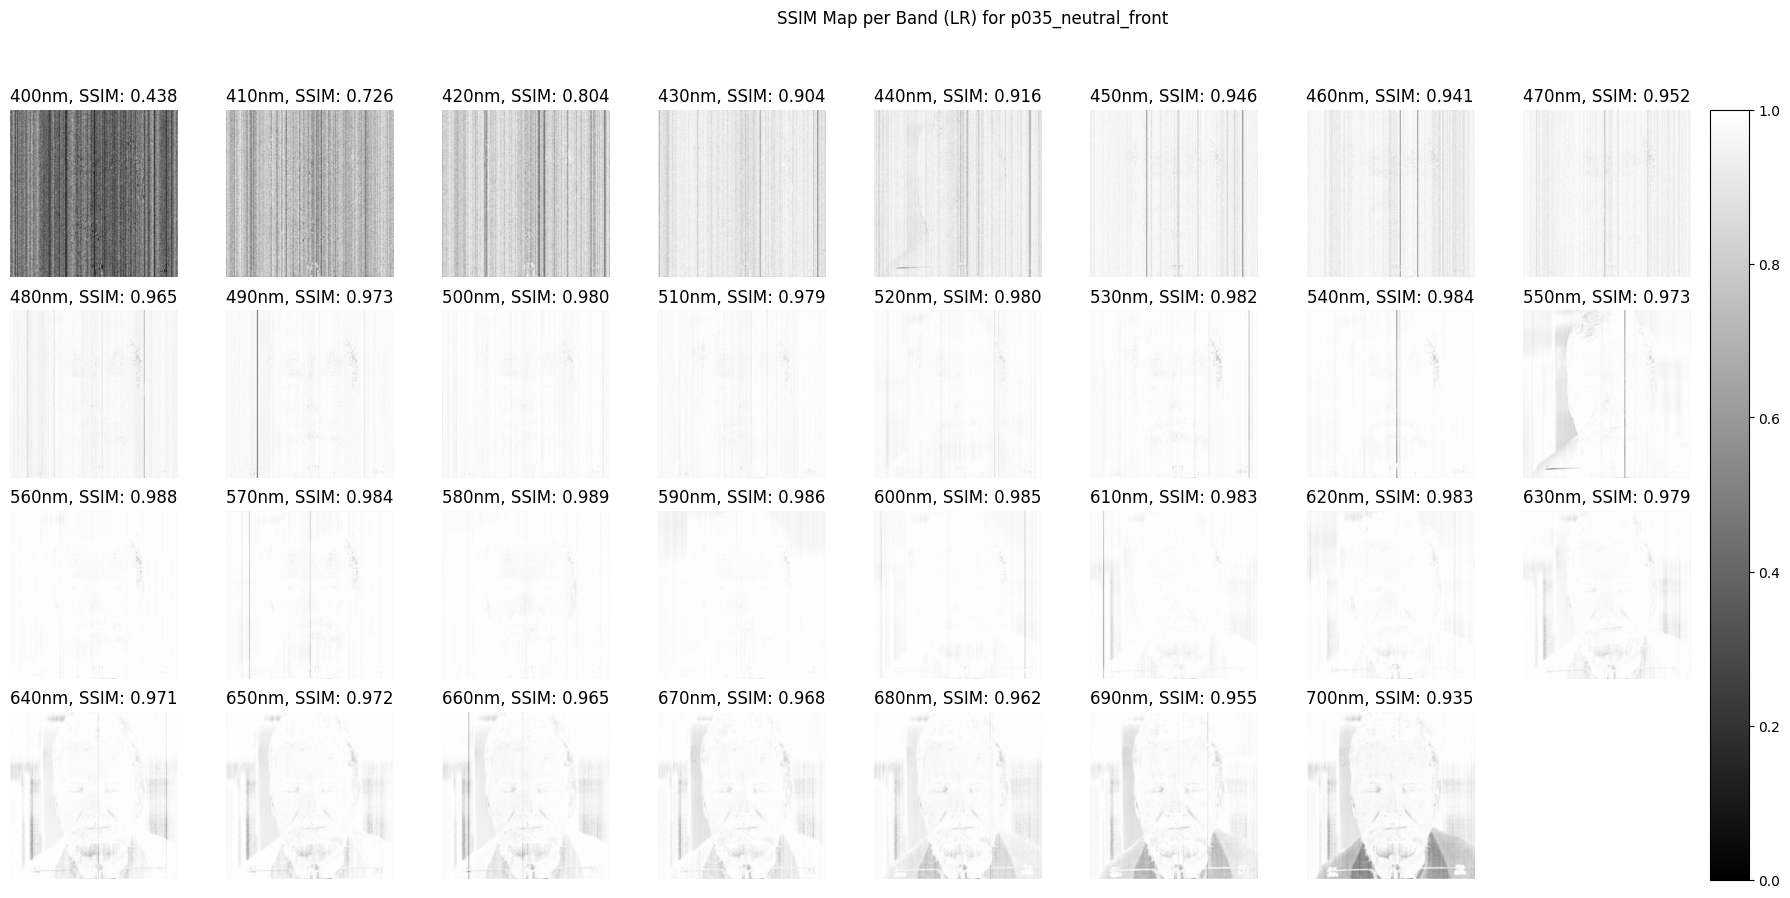

In [12]:
band_31 = np.arange(400, 710, 10)
ssim_map_lr = np.array(results_lr["ssim_map"]).squeeze()  # shape: [N, C, H, W]

fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(26, 10))
axes1d = axes.ravel()  # ndarray, not flatiter
for i in range(31):
    im = axes1d[i].imshow(ssim_map_lr[sample_idx, i, :, :], vmin=0, vmax=1, cmap='gray')
    axes1d[i].axis('off')
    axes1d[i].set_title(f"{band_31[i]}nm, SSIM: {ssim_map_lr[sample_idx, i, :, :].mean():.3f}")

# hide the extra (32nd) axis
axes1d[-1].axis('off')

fig.colorbar(im, ax=axes1d.tolist(), pad=0.01)
plt.suptitle(f'SSIM Map per Band (LR) for {filename}')
plt.show()

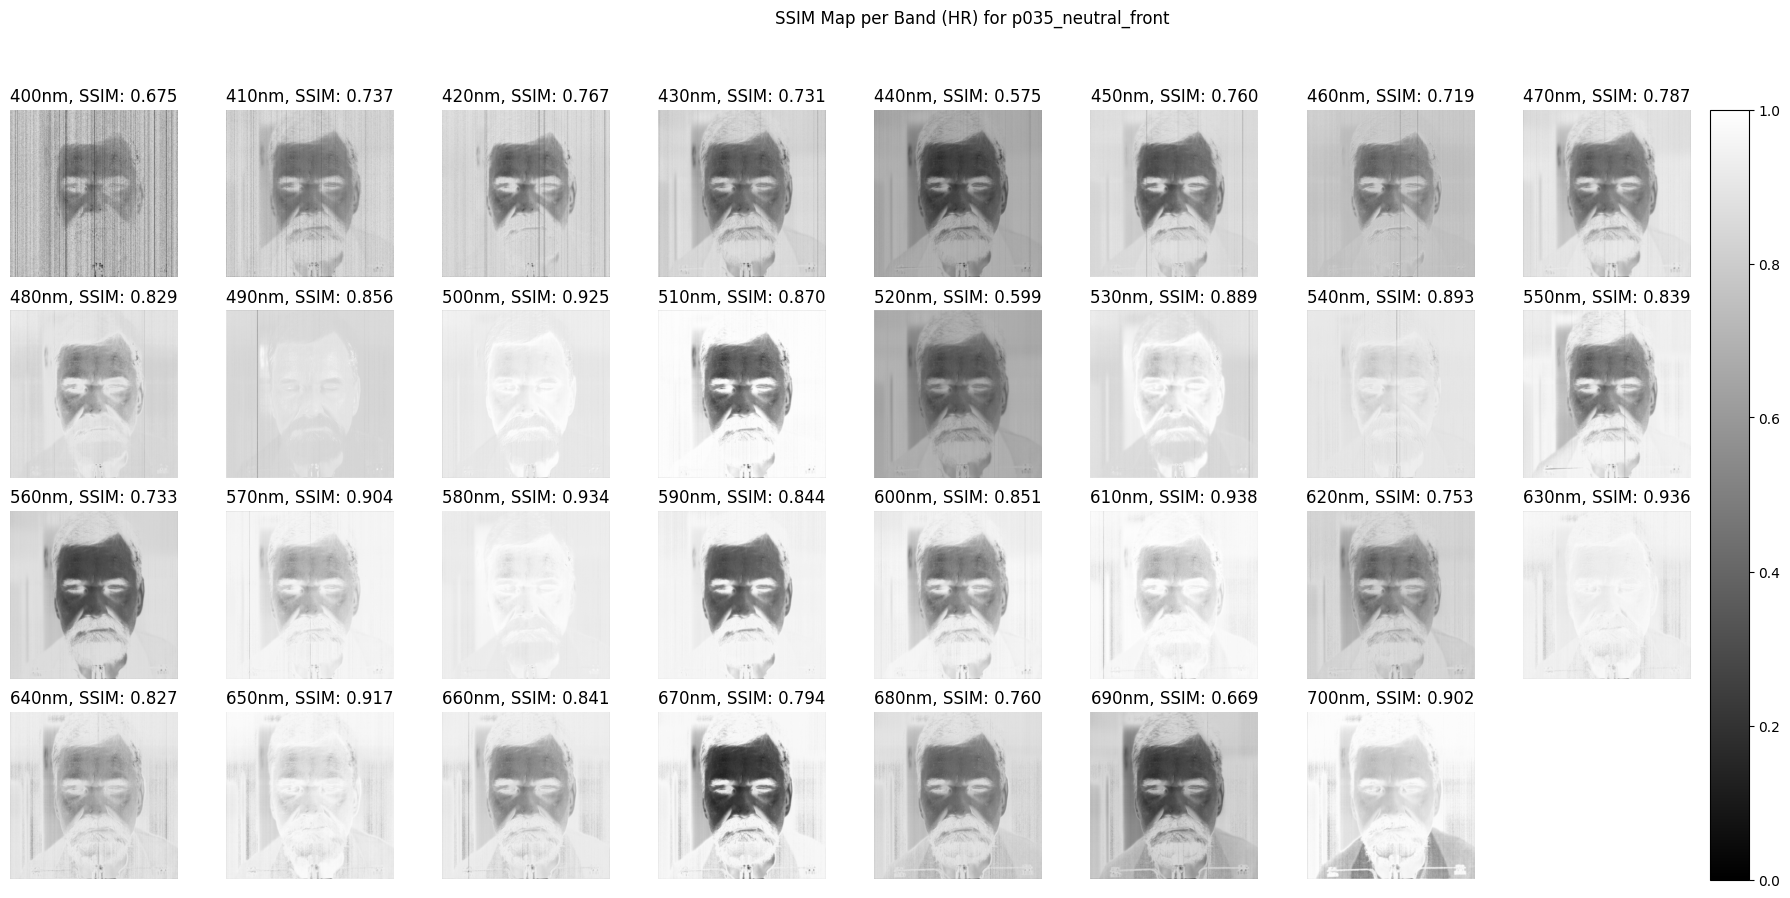

In [13]:
ssim_map_hr = np.array(results_hr["ssim_map"]).squeeze()  # shape: [N, C, H*UPSCALE, W*UPSCALE]

fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(26, 10))
axes1d = axes.ravel()
for i in range(31):
    im = axes1d[i].imshow(ssim_map_hr[sample_idx, i, :, :], vmin=0, vmax=1, cmap='gray')
    axes1d[i].axis('off')
    axes1d[i].set_title(f"{band_31[i]}nm, SSIM: {ssim_map_hr[sample_idx, i, :, :].mean():.3f}")

axes1d[-1].axis('off')

fig.colorbar(im, ax=axes1d.tolist(), pad=0.01)
plt.suptitle(f'SSIM Map per Band (HR) for {filename}')
plt.show()

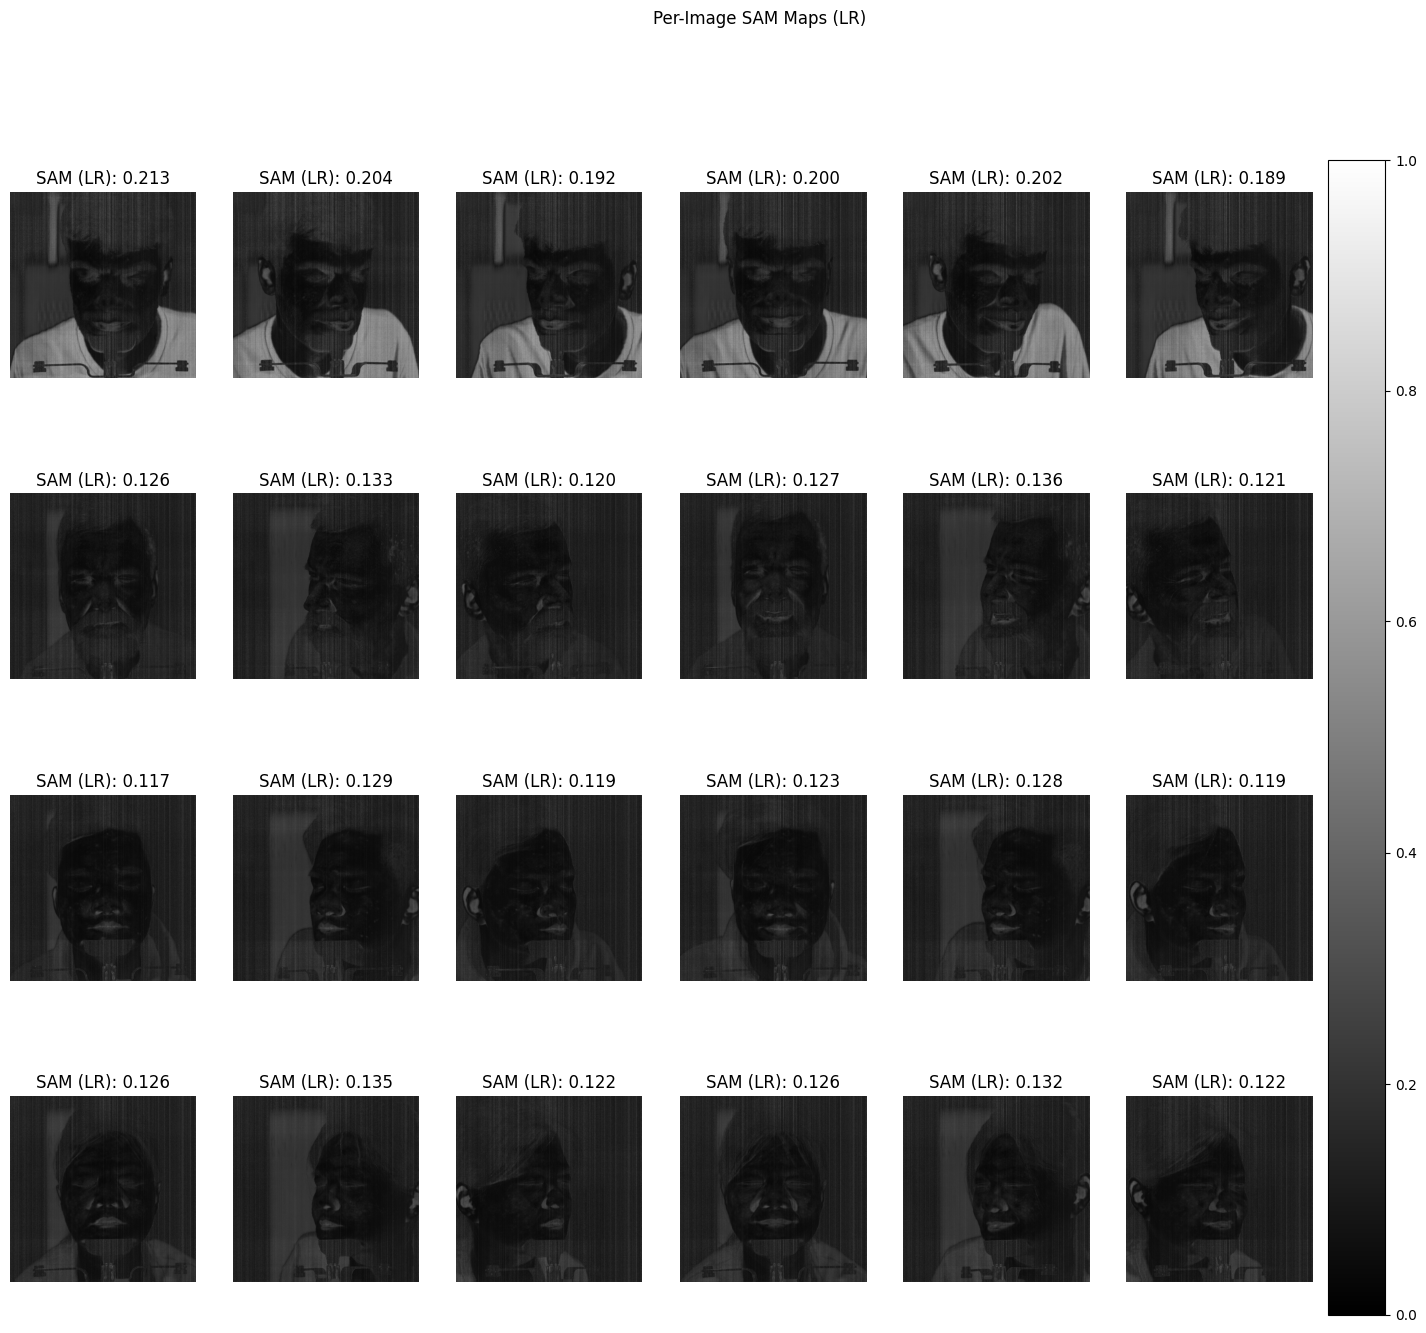

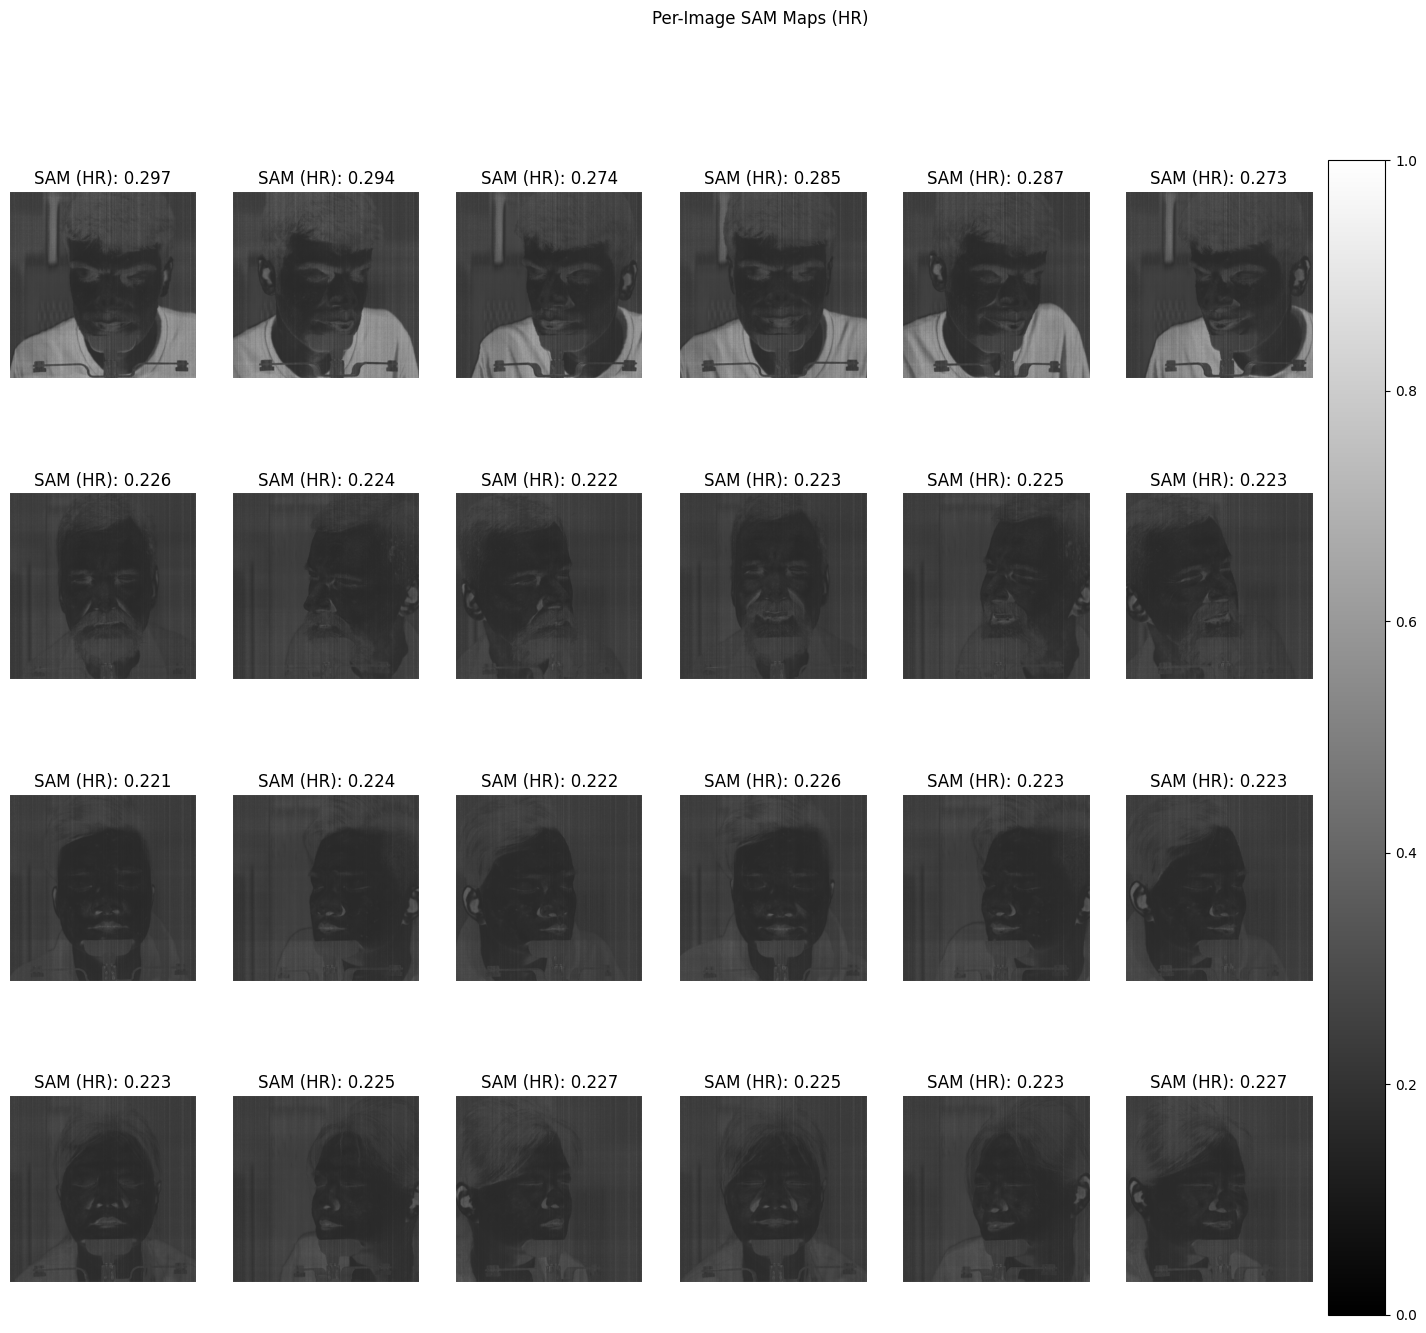

In [14]:
sam_map_lr_all = np.array(results_lr["sam_map"]).squeeze()
sam_map_hr_all = np.array(results_hr["sam_map"]).squeeze()

# LR grid
fig, axes = plt.subplots(4, 6, figsize=(20, 15))
axes = axes.flatten()
for img, ax in zip(sam_map_lr_all, axes):
    im = ax.imshow(img, vmin=0, vmax=1, cmap='gray')
    ax.axis('off')
    ax.set_title(f"SAM (LR): {img.mean():.3f}")
for ax in axes[len(sam_map_lr_all):]:
    ax.axis('off')
fig.colorbar(im, ax=axes.tolist(), pad=0.01)
plt.suptitle('Per-Image SAM Maps (LR)')
plt.show()

# HR grid
fig, axes = plt.subplots(4, 6, figsize=(20, 15))
axes = axes.flatten()
for img, ax in zip(sam_map_hr_all, axes):
    im = ax.imshow(img, vmin=0, vmax=1, cmap='gray')
    ax.axis('off')
    ax.set_title(f"SAM (HR): {img.mean():.3f}")
for ax in axes[len(sam_map_hr_all):]:
    ax.axis('off')
fig.colorbar(im, ax=axes.tolist(), pad=0.01)
plt.suptitle('Per-Image SAM Maps (HR)')
plt.show()

In [15]:
# Final Cell: Print resolutions (H x W x Channels) for Original, LR, and HR images

# Use existing sample_idx if defined, else default to 0
if 'sample_idx' not in locals() or sample_idx >= len(test_dataset):
    sample_idx = 0

# Fetch original sample (input RGB and GT HSI)
x_tensor, _ = test_dataset[sample_idx]  # x: [3, H, W]

# Fetch LR and HR predictions from stored results
# Each entry in results_*["pred"] is typically shape [1, C, H, W]; squeeze batch dim
pred_lr_arr = results_lr["pred"][sample_idx]
pred_hr_arr = results_hr["pred"][sample_idx]

if pred_lr_arr.ndim == 4:
    pred_lr_arr = pred_lr_arr[0]
if pred_hr_arr.ndim == 4:
    pred_hr_arr = pred_hr_arr[0]

# Shapes (convert CHW -> HxWxC when printing)
orig_H, orig_W, orig_C = x_tensor.shape[1], x_tensor.shape[2], x_tensor.shape[0]
lr_C, lr_H, lr_W = pred_lr_arr.shape[0], pred_lr_arr.shape[1], pred_lr_arr.shape[2]
hr_C, hr_H, hr_W = pred_hr_arr.shape[0], pred_hr_arr.shape[1], pred_hr_arr.shape[2]

print("Resolutions (H x W x Channels):")
print(f" - Original Image (Input RGB):        {orig_H} x {orig_W} x {orig_C}")
print(f" - LR Reconstructed Image (HSI):      {lr_H} x {lr_W} x {lr_C}")
print(f" - HR Reconstructed Image (HSI):      {hr_H} x {hr_W} x {hr_C}")

Resolutions (H x W x Channels):
 - Original Image (Input RGB):        1024 x 1024 x 3
 - LR Reconstructed Image (HSI):      1024 x 1024 x 31
 - HR Reconstructed Image (HSI):      2048 x 2048 x 31
